In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays

df_feat = pd.read_csv('raw_data/df_feat_processed.csv')
df_feat['ds'] = pd.to_datetime(df_feat['ds'])
print(df_feat.shape)

(66023, 29)


In [3]:
import pandas as pd
import numpy as np

df_feat = pd.read_csv('raw_data/df_feat_processed.csv')
df_feat['ds'] = pd.to_datetime(df_feat['ds'])

print(df_feat['target'].describe())
print(f'\nPercentil 75: {df_feat["target"].quantile(0.75):.2f}')
print(f'Percentil 90: {df_feat["target"].quantile(0.90):.2f}')
print(f'Percentil 95: {df_feat["target"].quantile(0.95):.2f}')

count    66023.000000
mean        93.442499
std         87.091001
min       -167.395000
25%         38.745000
50%         73.007500
75%        114.800000
max        500.000000
Name: target, dtype: float64

Percentil 75: 114.80
Percentil 90: 189.75
Percentil 95: 272.18


In [4]:
SPIKE_THRESHOLD = 200

df_feat['is_spike'] = (df_feat['target'] > SPIKE_THRESHOLD).astype(int)

print(f'Spikes: {df_feat["is_spike"].sum()} ({df_feat["is_spike"].mean()*100:.1f}% of data)')
print(f'Non-spikes: {(df_feat["is_spike"] == 0).sum()}')

Spikes: 5962 (9.0% of data)
Non-spikes: 60061


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Features para el clasificador (las mismas del Transformer)
feature_cols_spike = ['y_scaled', 'hour', 'day_of_week', 'day_of_year', 'month', 'year',
                      'lag_1h', 'lag_24h', 'lag_168h', 'ma_24h', 'ma_168h',
                      'generation', 'consumption', 'temperature_c', 'humidity_percent',
                      'cloud_cover_percent', 'shortwave_radiation_wm2',
                      'is_holiday', 'is_weekend', 'wind_onshore',
                      'target_hour', 'target_day_of_week', 'target_month',
                      'target_is_holiday', 'target_is_weekend']

split = int(len(df_feat) * 0.8)
X_train = df_feat[feature_cols_spike].iloc[:split]
X_test  = df_feat[feature_cols_spike].iloc[split:]
y_train = df_feat['is_spike'].iloc[:split]
y_test  = df_feat['is_spike'].iloc[split:]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Spikes in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train: (52818, 25) | Test: (13205, 25)
Spikes in test: 306 (2.3%)


In [6]:
# scale_pos_weight compensa el desbalance: non-spikes / spikes
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale:.1f}')

clf = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')

scale_pos_weight: 8.3
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     12899
           1       0.43      0.29      0.35       306

    accuracy                           0.97     13205
   macro avg       0.71      0.64      0.67     13205
weighted avg       0.97      0.97      0.97     13205

AUC-ROC: 0.9419


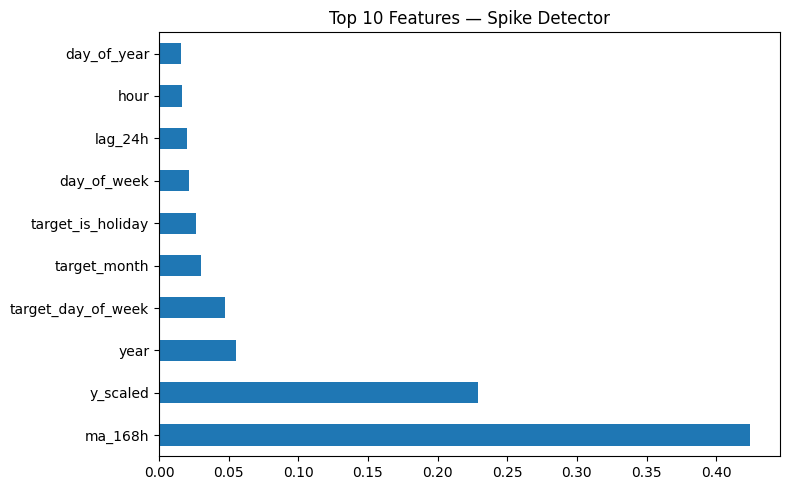

In [7]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(clf.feature_importances_, index=feature_cols_spike)
feat_imp.nlargest(10).plot(kind='barh', figsize=(8, 5))
plt.title('Top 10 Features — Spike Detector')
plt.tight_layout()
plt.show()

In [8]:
import joblib
joblib.dump(clf, 'models/spike_detector.pkl')
print('Spike detector saved')

Spike detector saved


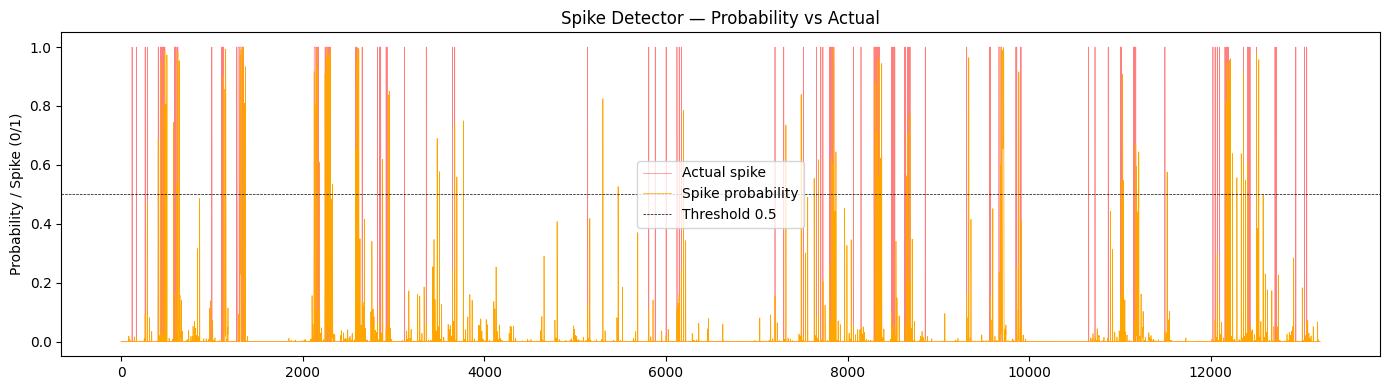

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar por probabilidad de spike
idx = np.arange(len(y_test))

plt.figure(figsize=(14, 4))
plt.plot(idx, y_test.values, label='Actual spike', color='red', alpha=0.5, linewidth=0.5)
plt.plot(idx, y_prob, label='Spike probability', color='orange', linewidth=0.5)
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=0.5, label='Threshold 0.5')
plt.title('Spike Detector — Probability vs Actual')
plt.ylabel('Probability / Spike (0/1)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# geting the results from V3 (transfomer)

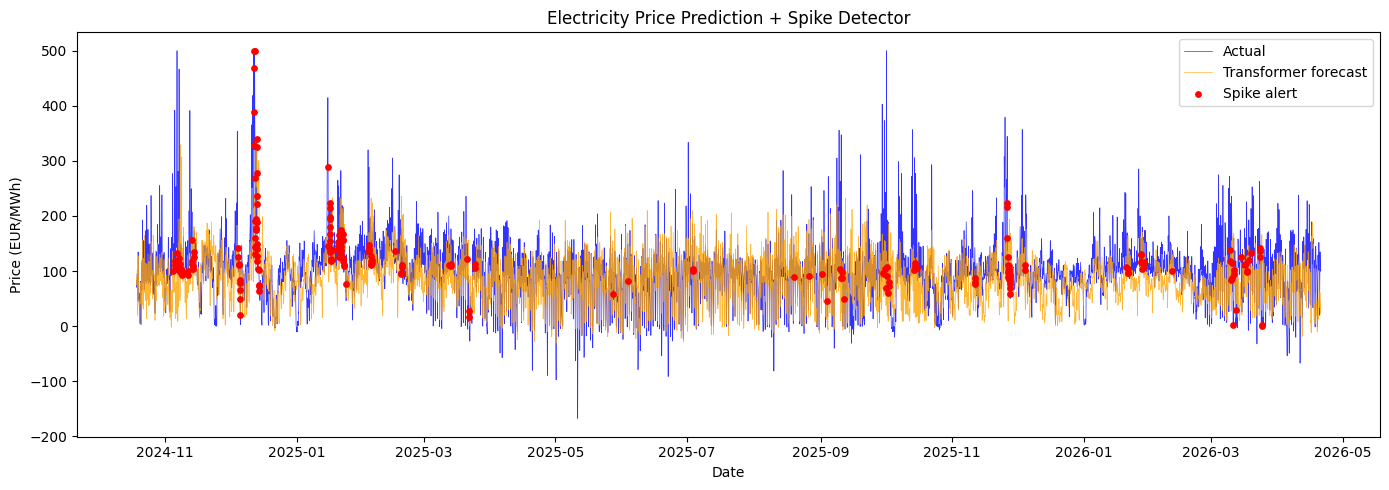

In [ ]:
# Load transformer predictions
preds_df = pd.read_csv('raw_data/transformer_predictions.csv')

# Align spike detector with transformer test set
# Both use 80/20 split so test indices match
spike_prob_test = y_prob[:len(preds_df)]

test_dates = df_feat['ds'].iloc[split + 24:].values

test_dates = df_feat['ds'].iloc[split + 24:split + 24 + len(preds_df)].values

n = min(len(test_dates), len(preds_df), len(spike_prob_test))
test_dates = test_dates[:n]

spike_idx = [i for i, p in enumerate(spike_prob_test[:n]) if p > 0.5]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, preds_df['y_test_real'].values[:n], label='Actual', color='blue', linewidth=0.5, alpha=0.8)
plt.plot(test_dates, preds_df['y_pred_real'].values[:n], label='Transformer forecast', color='orange', linewidth=0.5, alpha=0.8)
plt.scatter(test_dates[spike_idx], preds_df['y_test_real'].values[spike_idx],
            color='red', s=15, zorder=5, label='Spike alert')
plt.title('Electricity Price Prediction + Spike Detector')
plt.ylabel('Price (EUR/MWh)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
spike_idx = [i for i, p in enumerate(spike_prob_test) if p > 0.5]

mae_spikes = mean_absolute_error(
    preds_df['y_test_real'].values[spike_idx],
    preds_df['y_pred_real'].values[spike_idx]
)
mae_normal = mean_absolute_error(
    preds_df['y_test_real'].values[[i for i in range(len(preds_df)) if i not in spike_idx]],
    preds_df['y_pred_real'].values[[i for i in range(len(preds_df)) if i not in spike_idx]]
)

print(f'MAE on spike alerts: {mae_spikes:.2f} EUR/MWh')
print(f'MAE on normal periods: {mae_normal:.2f} EUR/MWh')

MAE on spike alerts: 40.29 EUR/MWh
MAE on normal periods: 32.41 EUR/MWh
